In [1]:
%pip install stopwordsiso


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import nltk
import nltk.corpus
from collections import Counter
from typing import List, Tuple
import stopwordsiso as stopwords  # multilingual stopwords
from nltk.corpus import stopwords as stopwords_nltk
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt

# Required corpora/resources
nltk.download('brown')
nltk.download('indian')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')

brown = nltk.corpus.brown
indian = nltk.corpus.indian

# Stopword lists
stop_words_in = stopwords.stopwords(["hi", "te"])
stopwords_en = set(stopwords_nltk.words('english'))

lemmatizer = WordNetLemmatizer()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/stopwordsiso/_core.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[nltk_data] Downloading package brown to
[nltk_data]     /Users/shreyabhatt/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package indian to
[nltk_data]     /Users/shreyabhatt/nltk_data...
[nltk_data]   Package indian is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/shreyabhatt/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/shreyabhatt/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]  

In [3]:
# Step 1
def ranked_frequency_list(words: List[str], corpus_name: str = "brown") -> List[Tuple[str, int]]:
    """
    Returns the full ranked frequency list (word, count), sorted by descending frequency.
    Brown: lowercase + alphabetic only + remove English stopwords + lemmatize
    Indian: lowercase + alphanumeric only + remove Hindi/Telugu stopwords
    """
    if corpus_name == 'indian':
        processed = [w.lower() for w in words if w.isalnum()]
        processed = [w for w in processed if w not in stop_words_in]
    else:
        processed = [w.lower() for w in words if w.isalpha()]
        processed = [w for w in processed if w not in stopwords_en]
        processed = [lemmatizer.lemmatize(w) for w in processed]

    return Counter(processed).most_common()


all_brown = ranked_frequency_list(brown.words(), corpus_name='brown')
all_religion = ranked_frequency_list(brown.words(categories='religion'), corpus_name='brown')
all_mystery = ranked_frequency_list(brown.words(categories='mystery'), corpus_name='brown')

print("Brown (top 10 preview):", all_brown[:10])
print("Religion (top 10 preview):", all_religion[:10])
print("Mystery (top 10 preview):", all_mystery[:10])

Brown (top 10 preview): [('one', 3408), ('would', 2714), ('said', 1961), ('time', 1898), ('new', 1635), ('year', 1608), ('could', 1601), ('may', 1415), ('two', 1414), ('state', 1410)]
Religion (top 10 preview): [('god', 138), ('church', 127), ('one', 110), ('new', 99), ('world', 95), ('may', 79), ('spirit', 71), ('would', 69), ('man', 68), ('life', 62)]
Mystery (top 10 preview): [('said', 204), ('would', 189), ('one', 182), ('back', 159), ('could', 145), ('like', 139), ('man', 107), ('get', 105), ('know', 93), ('two', 89)]


In [ ]:
# Step 2
def extract_insights(corpus, category=None, language=None):
    if category is not None:
        words = corpus.words(categories=category)
        sents = corpus.sents(categories=category)
        label = f"Brown category = {category}"
        corpus_name = "brown"
    elif language is not None:
        fileid = language + '.pos'
        words = corpus.words(fileid)
        sents = corpus.sents(fileid)
        label = f"Indian language = {language}"
        corpus_name = "indian"
    else:
        words = corpus.words()
        sents = corpus.sents()
        label = "Full corpus"
        corpus_name = "brown" if corpus == brown else "indian"

    # (i) number of tokens
    n_tokens = len(words)

    # (ii) number of types
    n_types = len(set(words))

    # processed "words" for downstream stats
    if corpus_name == "brown":
        word_list = [w.lower() for w in words if w.isalpha()]
        sent_lengths = [len([w for w in s if w.isalpha()]) for s in sents]
        lemmas = [lemmatizer.lemmatize(w) for w in word_list]
        n_lemmas = len(set(lemmas))
    else:
        word_list = [w.lower() for w in words if w.isalnum()]
        sent_lengths = [len([w for w in s if w.isalnum()]) for s in sents]
        # NLTK's WordNetLemmatizer is English-only, and there's no equivalent Hindi/Telugu lemmatizer available therefore it is defined as N/A.
        n_lemmas = "N/A"

    # (iii) number of words
    n_words = len(word_list)

    # (iv) average number of words per sentence
    avg_words_sent = sum(sent_lengths) / len(sent_lengths)

    # (v) average word length
    avg_word_len = sum(len(w) for w in word_list) / len(word_list)

    # (vi) number of lemmas
    print(f"\n{label}")
    print(f"Number of tokens: {n_tokens}")
    print(f"Number of types: {n_types}")
    print(f"Number of words: {n_words}")
    print(f"Average words per sentence: {avg_words_sent:.2f}")
    print(f"Average word length: {avg_word_len:.2f}")
    print(f"Number of lemmas: {n_lemmas}")


extract_insights(brown)
extract_insights(brown, category='religion')
extract_insights(brown, category='mystery')


Full corpus
Number of tokens: 1161192
Number of types: 56057
Number of words: 981716
Average words per sentence: 17.12
Average word length: 4.68
Number of lemmas: 34998

Brown category = religion
Number of tokens: 39399
Number of types: 6373
Number of words: 33958
Average words per sentence: 19.79
Average word length: 4.70
Number of lemmas: 5042

Brown category = mystery
Number of tokens: 57169
Number of types: 6982
Number of words: 46607
Average words per sentence: 11.99
Average word length: 4.22
Number of lemmas: 5556


In [5]:
# Step 3
# Brown: use NLTK's default English POS tagger on the corpus tokens
brown_tokens_for_tagging = [w for w in brown.words() if w.isalpha()]
brown_tagged = nltk.pos_tag(brown_tokens_for_tagging)
brown_tag_freqs = Counter(tag for _, tag in brown_tagged)

print("Brown POS tags (top 10, default NLTK tagger):")
print(brown_tag_freqs.most_common(10))

Brown POS tags (top 10, default NLTK tagger):
[('NN', 153004), ('IN', 136198), ('DT', 114731), ('JJ', 74506), ('NNP', 66057), ('NNS', 53840), ('VBD', 46675), ('RB', 44906), ('PRP', 44048), ('CC', 37946)]


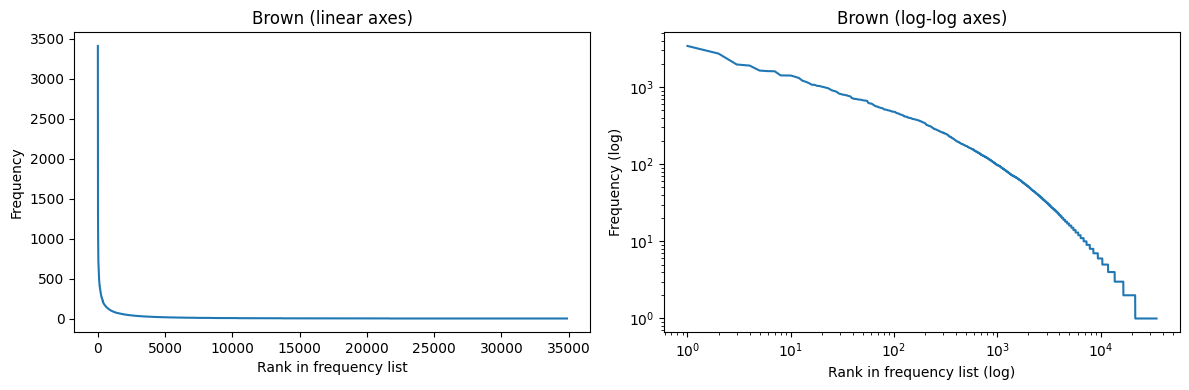

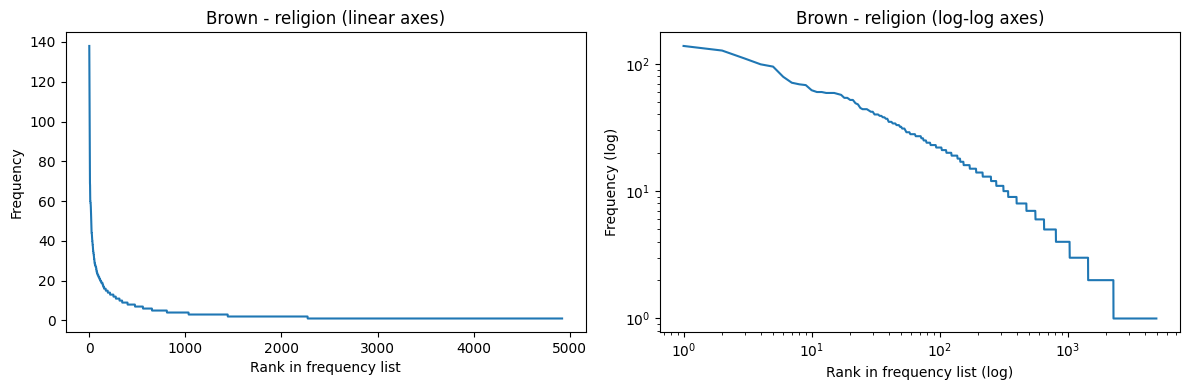

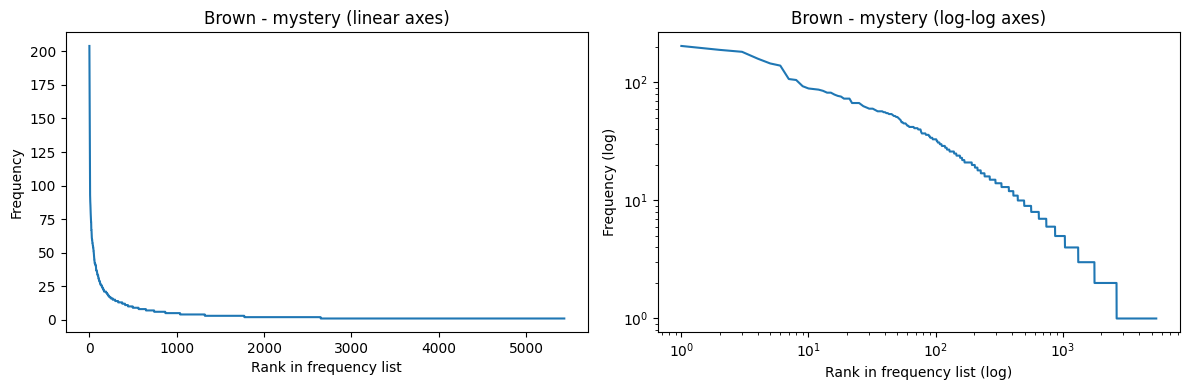

In [6]:
# Step 4
def plot_frequency_distribution(ranked_list, title):
    ranks = list(range(1, len(ranked_list) + 1))
    freqs = [count for _, count in ranked_list]

    plt.figure(figsize=(12, 4))

    # Linear plot
    plt.subplot(1, 2, 1)
    plt.plot(ranks, freqs)
    plt.xlabel('Rank in frequency list')
    plt.ylabel('Frequency')
    plt.title(f'{title} (linear axes)')

    # Log-log plot
    plt.subplot(1, 2, 2)
    plt.loglog(ranks, freqs)
    plt.xlabel('Rank in frequency list (log)')
    plt.ylabel('Frequency (log)')
    plt.title(f'{title} (log-log axes)')

    plt.tight_layout()
    plt.show()


plot_frequency_distribution(all_brown, 'Brown')
plot_frequency_distribution(all_religion, 'Brown - religion')
plot_frequency_distribution(all_mystery, 'Brown - mystery')

Indian full corpus (top 10 preview): [('৷', 840), ('ఈ', 112), ('হয়', 110), ('ఆ', 93), ('এই', 62), ('रन', 60), ('ও', 57), ('ఒక', 56), ('तर', 52), ('आज', 46)]
Hindi (top 10 preview): [('रन', 60), ('गई', 26), ('गए', 15), ('मदद', 15), ('बजट', 14), ('हरभजन', 14), ('अब', 12), ('रपट', 11), ('समय', 10), ('तरफ', 10)]
Telugu (top 10 preview): [('ఈ', 112), ('ఆ', 93), ('ఒక', 56), ('తన', 30), ('2', 17), ('ఏ', 16), ('తమ', 16), ('1', 15), ('3', 15), ('4', 13)]

Full corpus
Number of tokens: 48754
Number of types: 16143
Number of words: 4238
Average words per sentence: 1.17
Average word length: 1.90
Number of lemmas: N/A

Indian language = hindi
Number of tokens: 9408
Number of types: 2186
Number of words: 1210
Average words per sentence: 2.24
Average word length: 2.26
Number of lemmas: N/A

Indian language = telugu
Number of tokens: 9999
Number of types: 4209
Number of words: 553
Average words per sentence: 0.56
Average word length: 1.51
Number of lemmas: N/A

Hindi POS tags (top 10, corpus-provided 

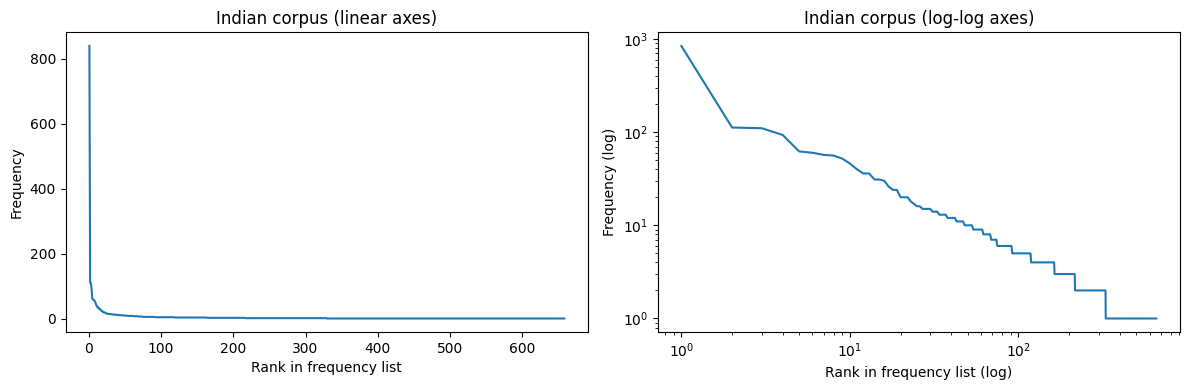

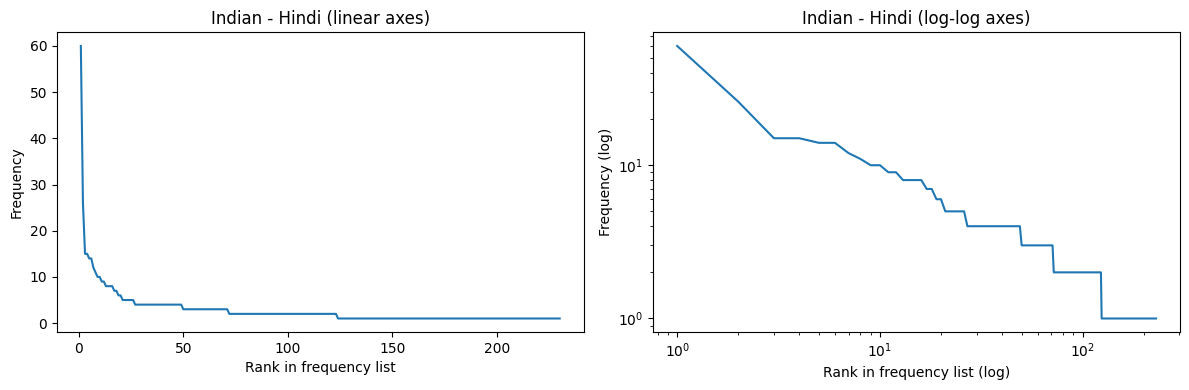

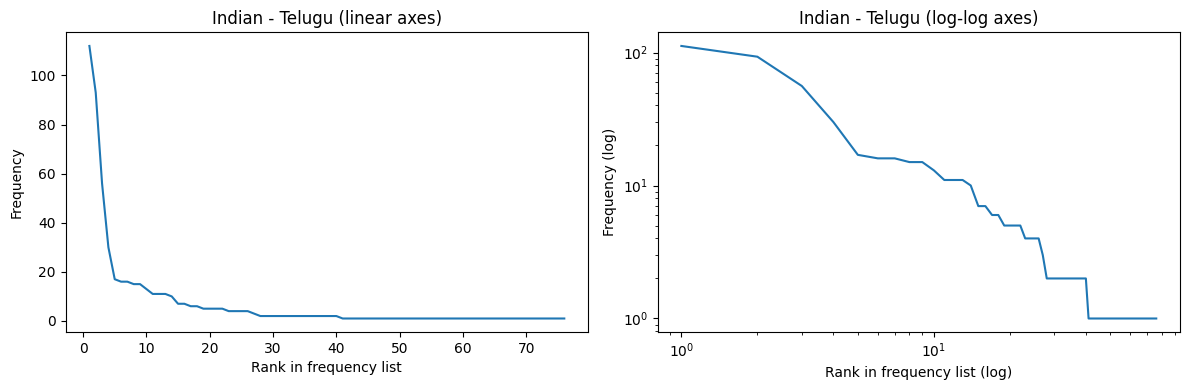

In [ ]:
# Step 5: Repeat for the Indian Language Corpus

# 5.1 Ranked frequency lists
all_indian = ranked_frequency_list(indian.words(), corpus_name='indian')
all_hindi = ranked_frequency_list(indian.words('hindi.pos'), corpus_name='indian')
all_telugu = ranked_frequency_list(indian.words('telugu.pos'), corpus_name='indian')

print("Indian full corpus (top 10 preview):", all_indian[:10])
print("Hindi (top 10 preview):", all_hindi[:10])
print("Telugu (top 10 preview):", all_telugu[:10])

# 5.2 Step 2 statistics
extract_insights(indian)
extract_insights(indian, language='hindi')
extract_insights(indian, language='telugu')

# 5.3 POS tags
# NLTK's default POS tagger is trained on English.
# Running it on Hindi/Telugu produces unreliable tags since the model has no
# knowledge of those languages' morphosyntax. We use the corpus-provided tags instead.

tag_freqs_hindi = Counter(tag for _, tag in indian.tagged_words('hindi.pos'))
tag_freqs_telugu = Counter(tag for _, tag in indian.tagged_words('telugu.pos'))

print("\nHindi POS tags (top 10, corpus-provided tags):")
print(tag_freqs_hindi.most_common(10))

print("\nTelugu POS tags (top 10, corpus-provided tags):")
print(tag_freqs_telugu.most_common(10))

# 5.4 Frequency curves
plot_frequency_distribution(all_indian, 'Indian corpus')
plot_frequency_distribution(all_hindi, 'Indian - Hindi')
plot_frequency_distribution(all_telugu, 'Indian - Telugu')